# Loan Approval Prediction

---

###  Business Problem

Banks receive thousands of loan applications every year.
**Manually reviewing each one is slow, inconsistent, and expensive.**
The ability to **automatically predict whether a loan should be approved or rejected**
based on applicant financial data is one of the most high-impact applications of ML in the FinTech industry.

> **Loan Default** = A borrower who is unable to repay the loan — leading to financial loss for the bank.

---

###  Objective

Build a Machine Learning model capable of:
- **Predicting loan approval or rejection** based on applicant financial profile
- **Minimizing risk** by identifying applicants unlikely to repay
- Delivering **actionable insights** for Credit Risk and Lending teams

---

###  Dataset

| Property | Details |
|---|---|
| **Source** | Loan Approval Dataset (Kaggle) |
| **Size** | ~4,269 applications |
| **Target** | `loan_status` — Approved / Rejected |
| **Features** | Demographics, income, assets, CIBIL score, loan terms |

---

## Importing Necessary Libraries

> Here we import all libraries needed throughout the project — from data processing (`pandas`, `numpy`), to visualization (`matplotlib`, `seaborn`), to ML algorithms and evaluation tools from `sklearn`. We also configure default plot styles upfront to keep visuals consistent across the entire notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             classification_report)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize'   : (9, 5),
    'figure.dpi'       : 120,
    'axes.titlesize'   : 14,
    'axes.titlepad'    : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'ytick.labelsize'  : 10,
    'xtick.labelsize'  : 10,
})

## Data Collection & Loading
> We load the dataset from a CSV file. This is always the first step in any ML project — you need to get the raw data into memory before doing anything else. We also strip whitespace from column names and string values to avoid silent bugs downstream.

In [ ]:
data = pd.read_csv("Dataset/loan_approval_dataset.csv")

# Strip whitespace from column names and string columns
data.columns = data.columns.str.strip()
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].str.strip()

## Data Understanding

> Before making any changes to the data, we need to understand it first. We inspect the dataset shape, column types, and value distributions — this helps us identify potential issues and plan our preprocessing strategy.

### · Shape & Columns
> We check the number of rows and columns, and the data type of each feature (numeric / object). This determines which columns need encoding and which can be used directly.

In [3]:
print(f'Shape : {data.shape[0]} rows x {data.shape[1]} columns')
print('Columns :')
print(data.dtypes.to_string())

Shape : 4269 rows x 13 columns
Columns :
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object


### · Binary & Categorical Features Distribution
> Categorical columns (Education, Self-Employed) and the target (`loan_status`) have a limited set of values. We inspect their distribution early to detect any **class imbalance** or rare categories before modeling.

In [4]:
cat_preview = ['education', 'self_employed', 'loan_status']
for col in cat_preview:
    print(f'\nColumn: {col}')
    print(data[col].value_counts())


Column: education
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Column: self_employed
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

Column: loan_status
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


### · Sample Rows
> We display the first and last rows of the dataset. This reveals the actual structure of the data and any formatting issues or unexpected values that are not visible in the dtype summary.

In [5]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
data.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


### · Basic Statistics
> We compute descriptive statistics such as mean, standard deviation, min, and max for key columns. This helps identify potential outliers and gives us a sense of each feature's value range.

In [7]:
cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]
data[cols].describe().round(2)

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.0,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2.5,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1.7,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,0.0,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1.0,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,3.0,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,4.0,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,5.0,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


## Data Cleaning
> Clean data leads to better models. In this stage we remove duplicates and handle missing values, then detect outliers — all before any analysis or modeling begins.

### · Duplicate Rows
> Duplicate rows cause the model to over-learn the same information and can bias results. We remove them if found.

In [8]:
dup_counts = data.duplicated().sum()
if dup_counts > 0:
    data = data.drop_duplicates()
    print(f'Duplicates Removed. New Shape : {data.shape}')
else:
    print('No Duplicates , Dataset Is Clean.')

No Duplicates , Dataset Is Clean.


### · Missing Values
> Missing values cause errors in modeling or skew results. We identify which columns have gaps and their percentage, then decide on the appropriate handling strategy.

In [9]:
missing     = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df.to_string())

                          Missing Count  Missing %
loan_id                               0        0.0
no_of_dependents                      0        0.0
education                             0        0.0
self_employed                         0        0.0
income_annum                          0        0.0
loan_amount                           0        0.0
loan_term                             0        0.0
cibil_score                           0        0.0
residential_assets_value              0        0.0
commercial_assets_value               0        0.0
luxury_assets_value                   0        0.0
bank_asset_value                      0        0.0
loan_status                           0        0.0


### · Outlier Detection (IQR Method)

> We use the **IQR Rule** to detect outliers in continuous columns. Detecting outliers does not necessarily mean removing them — they may carry real signal — but we need to be aware of them before modeling.

In [10]:
numeric_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

outlier_summary = []
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_out = ((data[col] < lower) | (data[col] > upper)).sum()

    outlier_summary.append({
        'Column'      : col,
        'Outliers'    : n_out,
        'Lower Bound' : round(lower, 2),
        'Upper Bound' : round(upper, 2)
    })

out_df = pd.DataFrame(outlier_summary).set_index('Column')
print(out_df)
print(f'\nTotal outliers detected: {out_df["Outliers"].sum()}')

                          Outliers  Lower Bound  Upper Bound
Column                                                      
no_of_dependents                 0         -3.5          8.5
income_annum                     0   -4500000.0   14700000.0
loan_amount                      0  -13000000.0   42200000.0
loan_term                        0         -9.0         31.0
cibil_score                      0         10.5       1190.5
residential_assets_value        52  -11450000.0   24950000.0
commercial_assets_value         37   -8150000.0   17050000.0
luxury_assets_value              0  -13800000.0   43000000.0
bank_asset_value                 5   -4900000.0   14300000.0

Total outliers detected: 94


### · Boxplot For Numerical Features
> Boxplots visually highlight outliers and show the spread and distribution of each numeric feature. Much easier than raw numbers for spotting anomalies.

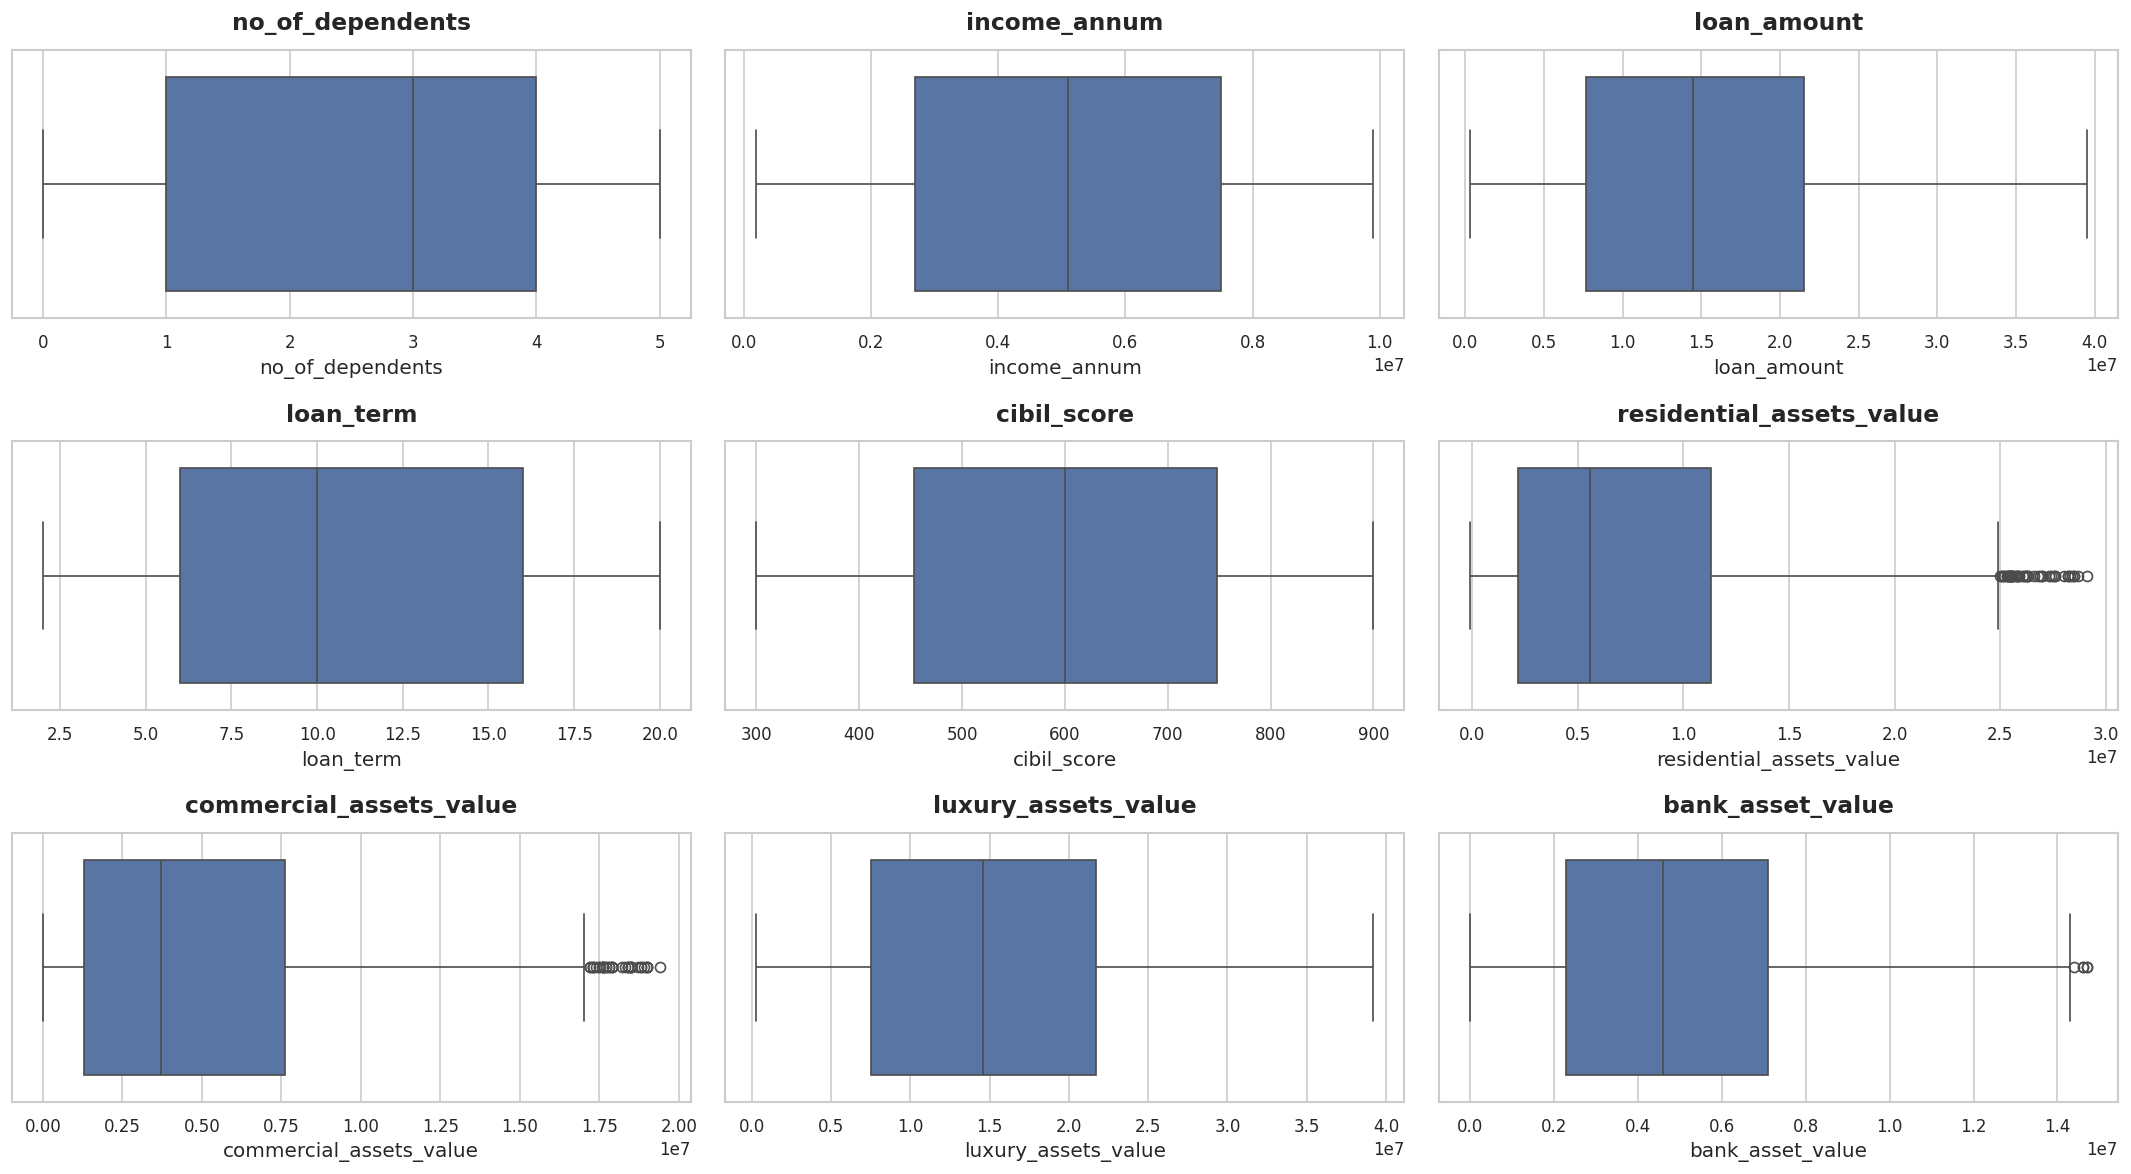

In [11]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### · Define Categorical Columns
> In this step, we define the categorical feature columns that will later be used for encoding. Defining them early helps keep the preprocessing pipeline more organized, readable, and easier to maintain.

In [12]:
cat_cols = [
    'education',
    'self_employed'
]

## EDA (Exploratory Data Analysis)
> EDA is the stage where we deeply understand the data — we examine the distribution of each variable and its relationship with the target (`loan_status`). The insights gained here drive Feature Engineering and Modeling decisions.

### · Univariate Analysis
> We study each variable independently to understand its distribution and shape — is it normal? skewed? dominated by a single value? This determines what transformations may be needed.

#### · Distribution For Numerical Columns
> We plot a Histogram with KDE for each numeric column to visualize its distribution shape and identify skewness or concentration around specific values.

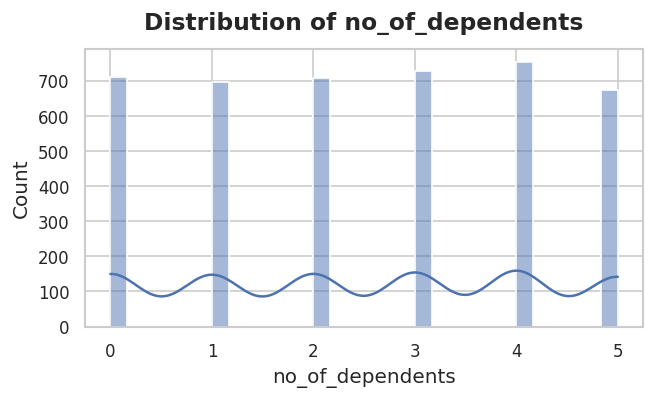

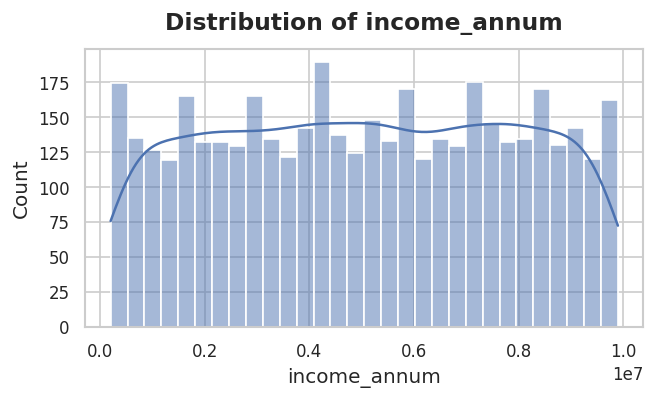

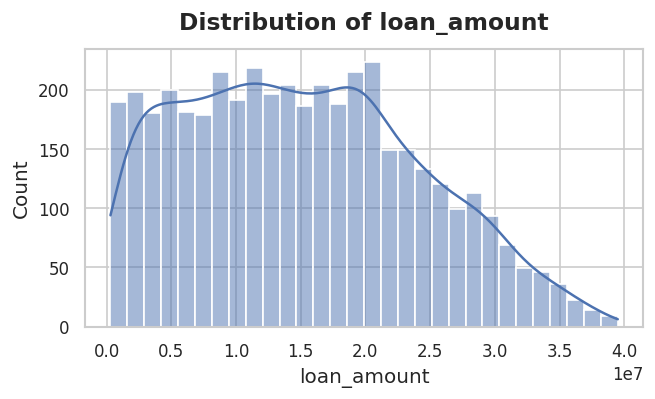

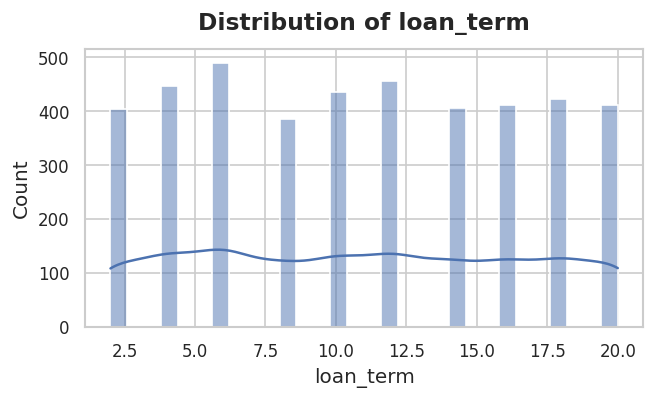

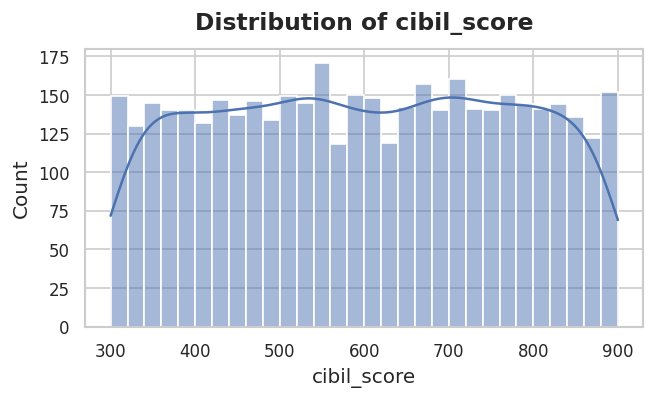

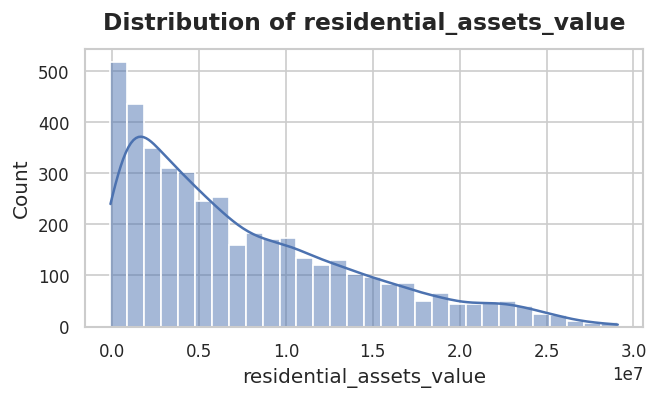

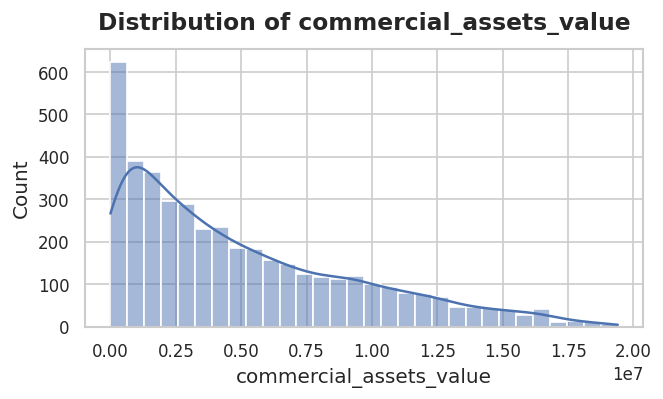

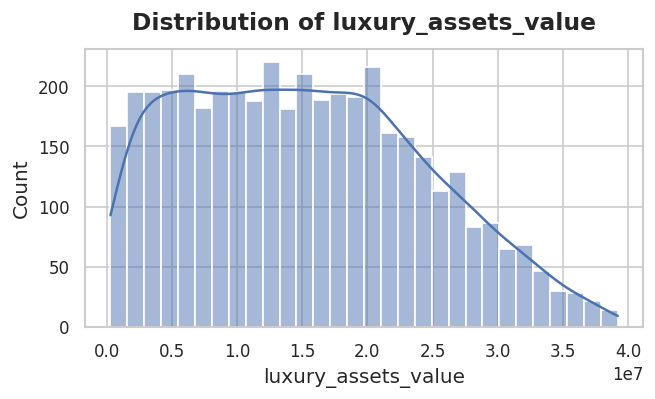

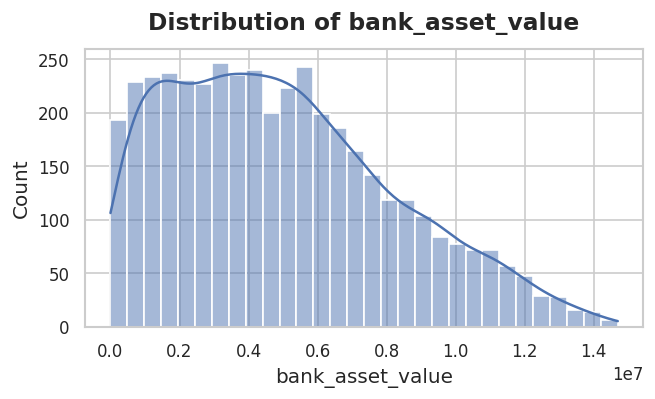

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

#### · Distribution For Categorical Columns
> We visualize the distribution of categorical features like Education and Self-Employment status — important for spotting rare categories that may need grouping.

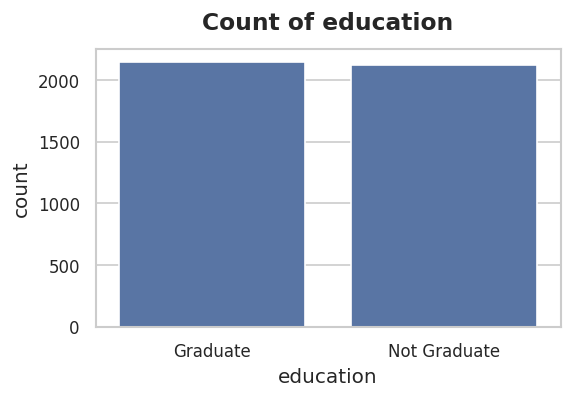

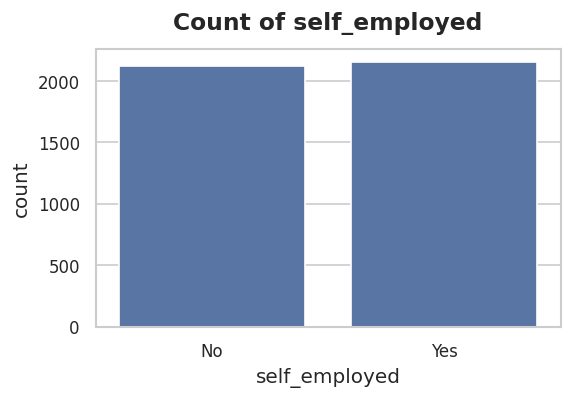

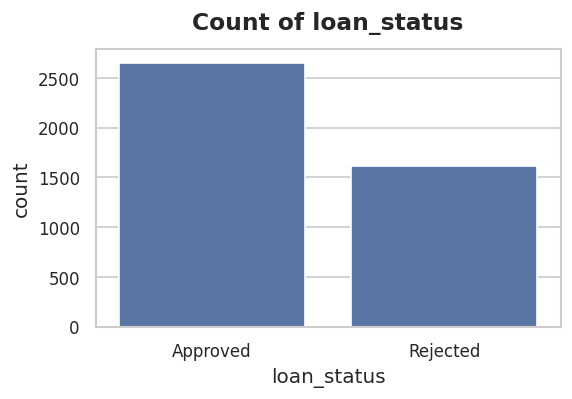

In [14]:
for col in cat_cols + ['loan_status']:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=data[col])
    plt.title(f'Count of {col}')
    plt.show()

### · Bivariate Analysis
> We study the relationship between each variable and the target (`loan_status`). This is the core of EDA in Classification problems — it reveals which features have real **predictive power**.

#### · CIBIL Score vs Loan Status
Analyzing whether credit score is a strong discriminator between approved and rejected applications.

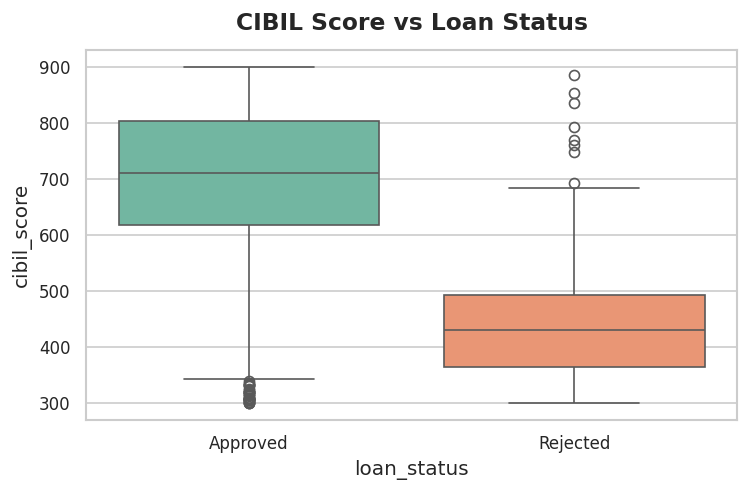

In [15]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='loan_status', y='cibil_score', data=data, palette='Set2')
plt.title('CIBIL Score vs Loan Status')
plt.show()

#### · Income vs Loan Status
Checking if annual income level significantly influences the approval decision.

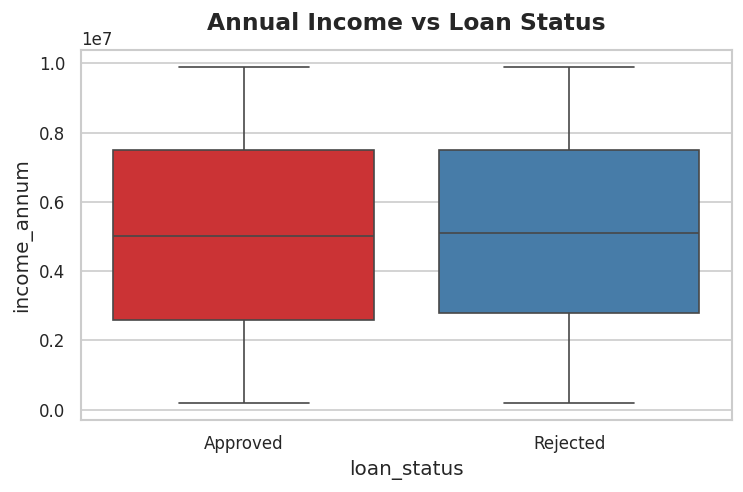

In [16]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='loan_status', y='income_annum', data=data, palette='Set1')
plt.title('Annual Income vs Loan Status')
plt.show()

#### · Loan Amount vs Loan Status
Understanding if higher loan amounts lead to more rejections.

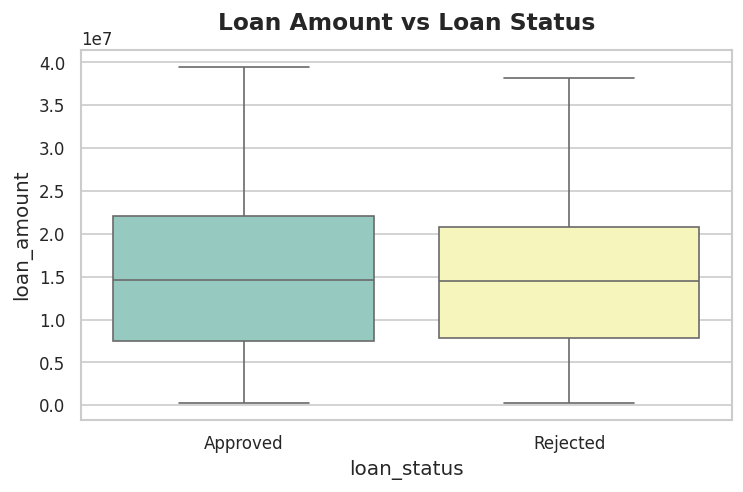

In [17]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='loan_status', y='loan_amount', data=data, palette='Set3')
plt.title('Loan Amount vs Loan Status')
plt.show()

#### · Education vs Loan Status
Analyzing whether education level affects loan approval rates.

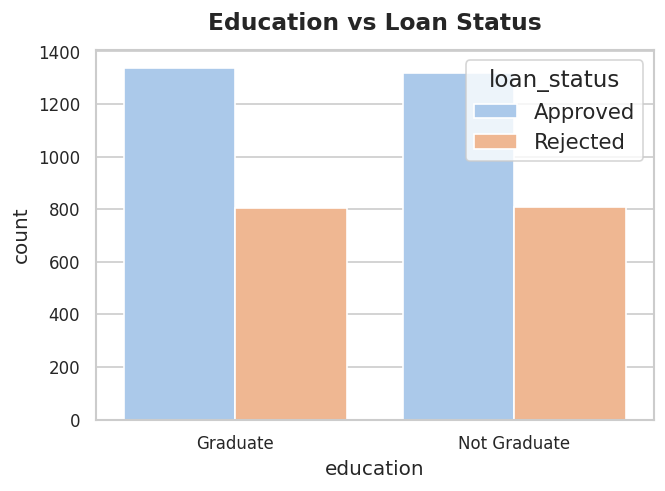

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='education', hue='loan_status', data=data, palette='pastel')
plt.title('Education vs Loan Status')
plt.show()

#### · Self Employment vs Loan Status
Checking if being self-employed correlates with higher rejection rates.

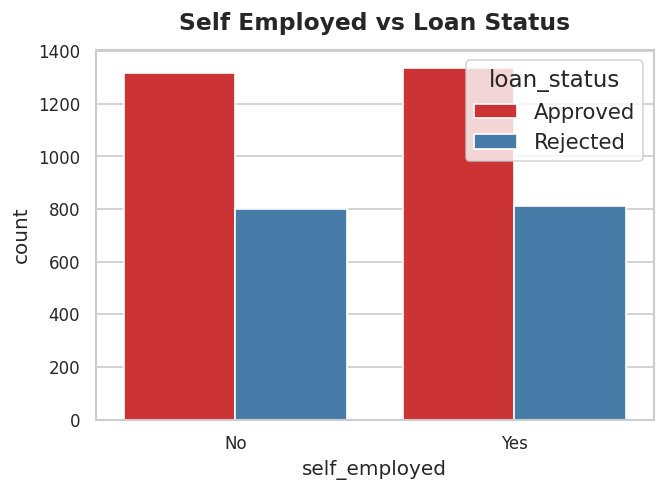

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x='self_employed', hue='loan_status', data=data, palette='Set1')
plt.title('Self Employed vs Loan Status')
plt.show()

#### · Number of Dependents vs Loan Status
Studying whether having more dependents affects the bank's approval decision.

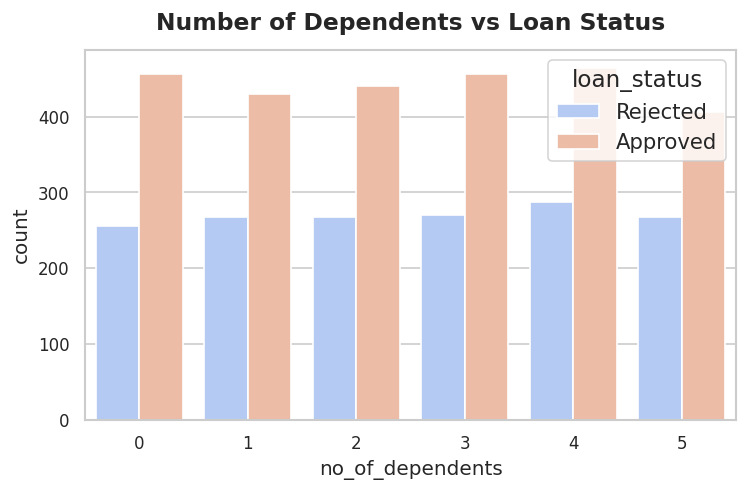

In [20]:
plt.figure(figsize=(7, 4))
sns.countplot(x='no_of_dependents', hue='loan_status', data=data, palette='coolwarm')
plt.title('Number of Dependents vs Loan Status')
plt.show()

#### · Total Assets vs Loan Status
Comparing total asset value between approved and rejected applicants.

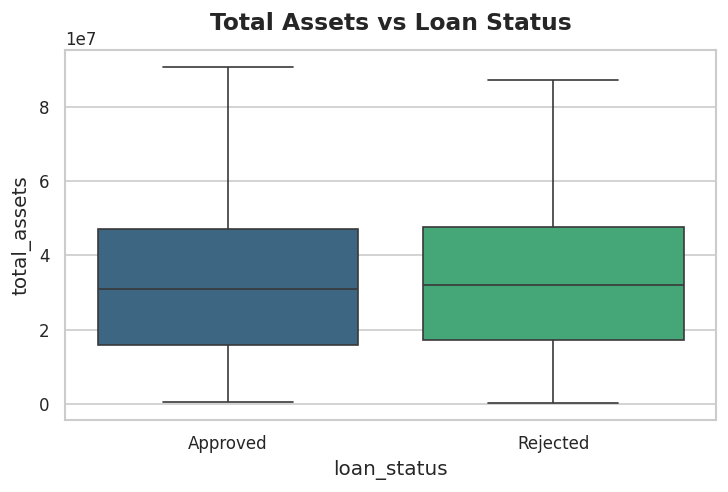

In [21]:
data['total_assets'] = (data['residential_assets_value'] +
                        data['commercial_assets_value'] +
                        data['luxury_assets_value'] +
                        data['bank_asset_value'])

plt.figure(figsize=(7, 4))
sns.boxplot(x='loan_status', y='total_assets', data=data, palette='viridis')
plt.title('Total Assets vs Loan Status')
plt.show()

# Drop temp column — will recreate properly in Feature Engineering
data.drop(columns=['total_assets'], inplace=True)

#### · Correlation Heatmap

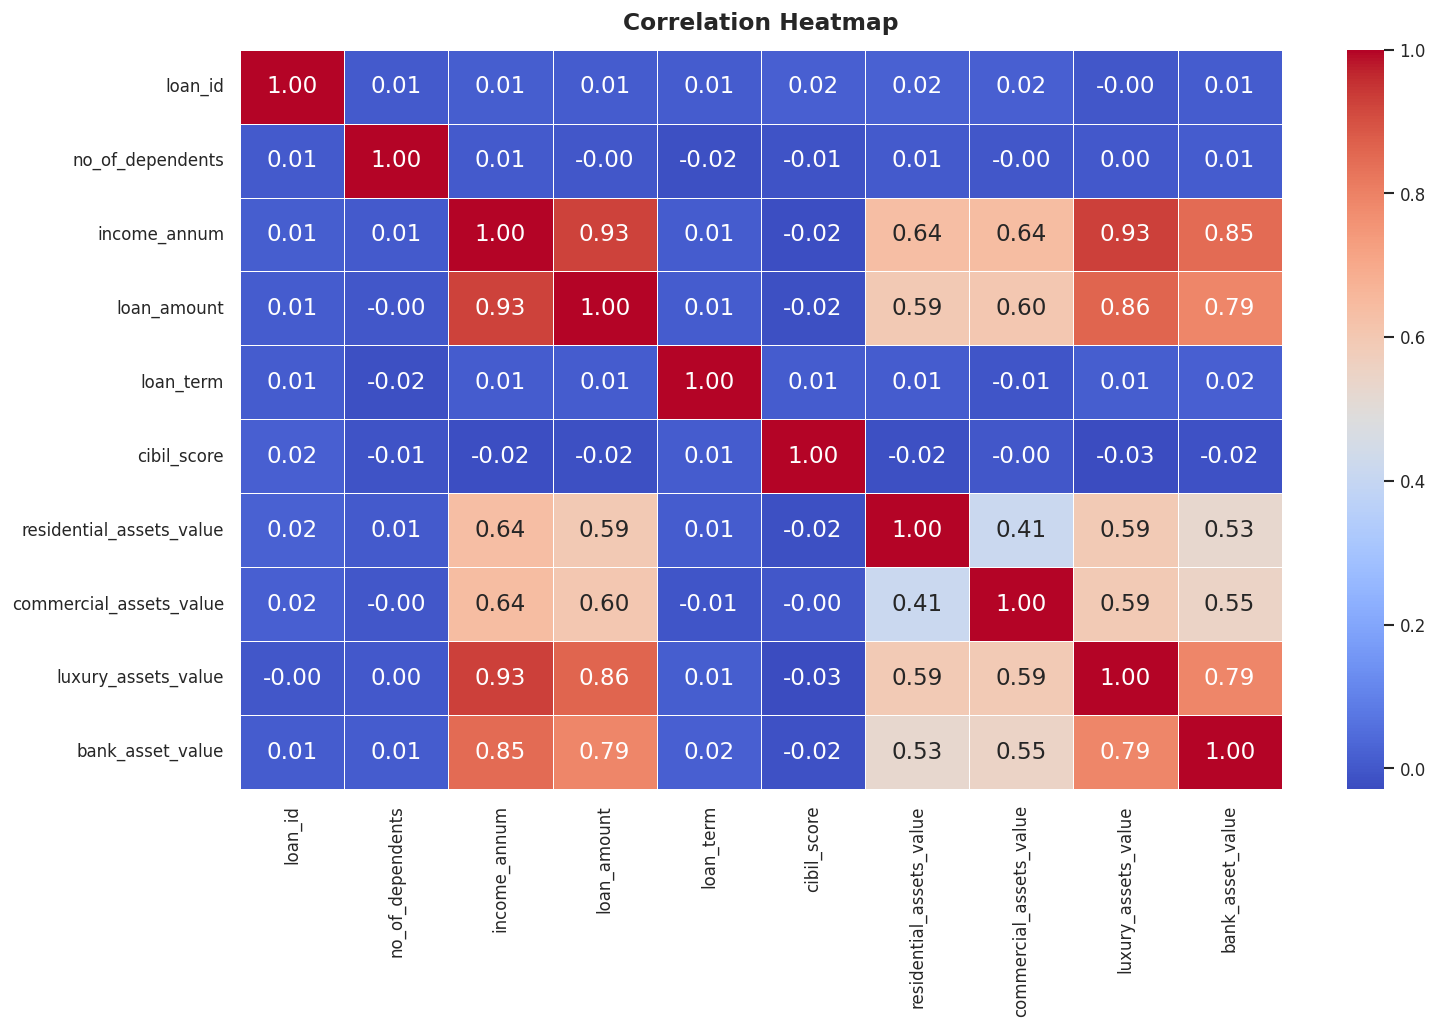

In [22]:
plt.figure(figsize=(14, 8))
corr = data.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

> Based on our EDA findings, we create **new features** not present in the raw data.
> Feature Engineering boosts the model's predictive power by expressing deeper relationships in the data.
> For example: the loan-to-income ratio is far more informative than raw loan amount alone,
> and total assets better capture overall financial strength than individual asset columns.

In [23]:
# Loan-to-Income Ratio — higher ratio = higher risk
data['LoanToIncomeRatio'] = data['loan_amount'] / (data['income_annum'] + 1)

# Total Assets — overall financial strength of applicant
data['TotalAssets'] = (data['residential_assets_value'] +
                       data['commercial_assets_value'] +
                       data['luxury_assets_value'] +
                       data['bank_asset_value'])

# Loan-to-Assets Ratio — how leveraged the applicant is relative to their wealth
data['LoanToAssetsRatio'] = data['loan_amount'] / (data['TotalAssets'] + 1)

# CIBIL Tier — categorical grouping of credit score ranges
data['CIBILTier'] = pd.cut(
    data['cibil_score'],
    bins=[0, 450, 600, 750, 900],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)

print(f'New features added: LoanToIncomeRatio, TotalAssets, LoanToAssetsRatio, CIBILTier')
print(f'New dataset shape: {data.shape}')
data[['LoanToIncomeRatio', 'TotalAssets', 'LoanToAssetsRatio', 'CIBILTier']].head()

New features added: LoanToIncomeRatio, TotalAssets, LoanToAssetsRatio, CIBILTier
New dataset shape: (4269, 17)


,LoanToIncomeRatio,TotalAssets,LoanToAssetsRatio,CIBILTier
0,3.114583,50700000,0.589744,Excellent
1,2.975609,17000000,0.717647,Poor
2,3.263736,57700000,0.514731,Fair
3,3.743902,52700000,0.582543,Fair
4,2.469388,55000000,0.440000,Poor


## Train / Test Split
> **This must come before any Preprocessing** — to prevent Data Leakage. If we apply Scaling or Encoding first, the model would have seen information from the test set during training, leading to inflated and misleading results. We use `stratify=y` to preserve the same Approval ratio in both train and test sets.

In [24]:
X = data.drop(['loan_status', 'loan_id'], axis=1)
y = (data['loan_status'] == 'Approved').astype(int)   # 1 = Approved, 0 = Rejected

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows')

Train size : 3415 rows
Test size  : 854 rows


## Preprocessing
> After splitting, we prepare the data for modeling. The order here is critical:
> 1. **Encoding** → Convert categorical features to numeric
> 2. **SMOTE** → Handle Class Imbalance on train set only
> 3. **Scaling** → Normalize feature magnitudes
>
> All transformations are fit on the train set only, then applied to the test set — never the reverse.

### · Encoding
> We convert categorical columns (Education, Self-Employed, CIBILTier) to numeric using `get_dummies`. We use `align` to ensure train and test have the same columns after encoding.

In [25]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### · Class Imbalance Check
> We verify the Approval ratio in the data. If the imbalance is significant, the model will be biased toward the majority class. This step justifies the use of SMOTE in the next step.

In [26]:
print('Class Counts:')
print(data['loan_status'].value_counts())
print()
print('Class proportions:')
print(data['loan_status'].value_counts(normalize=True).round(2))

Class Counts:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Class proportions:
loan_status
Approved    0.62
Rejected    0.38
Name: proportion, dtype: float64


### · Imbalancing Handling (SMOTE)
> **SMOTE (Synthetic Minority Over-sampling Technique)** generates synthetic samples for the minority class rather than simply duplicating existing ones. We apply it to the **training set only** to avoid data leakage from the test set.

In [27]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE — Class counts: {dict(pd.Series(y_train).value_counts())}')
print(f'After  SMOTE — Class counts: {dict(pd.Series(y_train_resampled).value_counts())}')

Before SMOTE — Class counts: {1: np.int64(2125), 0: np.int64(1290)}
After  SMOTE — Class counts: {1: np.int64(2125), 0: np.int64(2125)}


### · Scaling
> We normalize numeric column magnitudes using `StandardScaler`. This is critical for distance-based models like SVM and Logistic Regression. We `fit` the scaler on train only, then `transform` both train and test with the same fitted scaler.

In [28]:
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)

scale_cols = [
    'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
    'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value',
    'bank_asset_value', 'LoanToIncomeRatio', 'TotalAssets', 'LoanToAssetsRatio'
]

# Only keep scale_cols that actually exist after encoding
scale_cols = [c for c in scale_cols if c in X_train_resampled.columns]

scaler = ColumnTransformer(
    transformers=[('num', StandardScaler(), scale_cols)],
    remainder='passthrough'
)

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test)

## Model Building
> We train 4 different models — Logistic Regression, Random Forest, SVM, and Naive Bayes — with Hyperparameter Tuning for each. We use `RandomizedSearchCV` for simpler models and `HalvingRandomSearchCV` for Random Forest to save training time while covering a wider hyperparameter search space.

### Define Models & Parameter Grids
> We define the models alongside their hyperparameter search spaces. The parameter ranges chosen are based on best practices and domain knowledge for each algorithm.

In [29]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    'SVM': SVC(
        probability=True,
        random_state=42,
        class_weight='balanced'
    ),
    'NaiveBayes': GaussianNB()
}

param_grids = {
    'LogisticRegression': {
        'C'      : np.logspace(-3, 2, 6),
        'solver' : ['liblinear'],
        'penalty': ['l2']
    },
    'RandomForest': {
        'n_estimators'     : [300, 500, 700],
        'max_depth'        : [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'max_features'     : ['sqrt', 'log2', None]
    },
    'SVM': {
        'C'     : [0.1, 1, 10, 50, 100],
        'kernel': ['rbf'],
        'gamma' : ['scale', 0.01, 0.05, 0.1]
    },
    'NaiveBayes': {
        'var_smoothing': np.logspace(-12, -8, 5)
    }
}

### Training Loop with Hyperparameter Tuning
> We loop over each model, run a search for the best hyperparameters using ROC-AUC as the scoring metric, then evaluate on the hold-out test set. We use `HalvingRandomSearchCV` for tree-based models to efficiently handle the larger search space.

In [30]:
best_models = {}
results     = []

halving_models = {'RandomForest'}
n_iter_map     = {
    'LogisticRegression': 20,
    'RandomForest'      : 30,
    'SVM'               : 20,
    'NaiveBayes'        : 10
}

for name, model in models.items():

    print(f'\n{"="*60}')
    print(f' Training: {name}')
    print(f'{"="*60}')

    if name in halving_models:
        search = HalvingRandomSearchCV(
            model, param_grids[name],
            scoring='roc_auc',
            cv=3,
            verbose=1,
            n_jobs=-1,
            random_state=42
        )
    else:
        search = RandomizedSearchCV(
            model, param_grids[name],
            n_iter=n_iter_map[name],
            scoring='roc_auc',
            cv=3,
            verbose=1,
            n_jobs=-1,
            random_state=42
        )

    search.fit(X_train_scaled, y_train_resampled)

    best_model = search.best_estimator_
    best_models[name] = best_model

    print('\n Best Parameters:')
    print(search.best_params_)

    y_pred = best_model.predict(X_test_scaled)

    if hasattr(best_model, 'predict_proba'):
        y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = best_model.decision_function(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_prob)

    results.append({
        'Model'   : name,
        'Accuracy': round(accuracy, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC' : round(roc_auc, 4)
    })

    print('\n Classification Report:')
    print(classification_report(y_test, y_pred))

    print('\n Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

    print(f'\n Accuracy : {accuracy:.4f}')
    print(f' F1 Score : {f1:.4f}')
    print(f' ROC-AUC  : {roc_auc:.4f}')

results_df = pd.DataFrame(results)
print(f'\n{"="*60}')
print(' Models Comparison')
print(f'{"="*60}')
print(results_df.sort_values(by='ROC-AUC', ascending=False))


 Training: LogisticRegression
Fitting 3 folds for each of 6 candidates, totalling 18 fits

 Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'C': np.float64(100.0)}

 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       323
           1       0.96      0.92      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854


 Confusion Matrix:
[[303  20]
 [ 40 491]]

 Accuracy : 0.9297
 F1 Score : 0.9424
 ROC-AUC  : 0.9771

 Training: RandomForest
n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 12
max_resources_: 4250
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 324
n_resources: 12
Fitting 3 folds for each of 324 candidates, totalling 972 fits
----------
iter: 1
n_candidates: 108
n_resources: 36
Fitting 3 folds for each of 108 

## Cross-Validation (Generalization Check)

> The CV performed inside `RandomizedSearchCV` is only for selecting hyperparameters — not for evaluating the final model.
> Here we run **true Cross-Validation** using **Stratified K-Fold (5 folds)** to confirm that each model's performance is
> consistent across different data splits and not just a lucky result on the current test split.
>
> **Why Stratified K-Fold specifically for this project?**
> Our dataset has a **62% / 38% class imbalance** (Approved / Rejected).
> Stratified K-Fold guarantees that **each fold preserves the same Approved/Rejected ratio**,
> preventing folds with very few Rejected samples that would give misleading high accuracy.
>
> We use **ROC-AUC** as the scoring metric because it is **threshold-independent** —
> it measures the model's ability to **rank** approved vs rejected applicants correctly,
> regardless of where we set the decision threshold.
> Output: mean and standard deviation of ROC-AUC across 5 folds — high mean + low std = stable, generalizable model.

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print('Cross-Validation Results (5-Fold Stratified):')
print('Why Stratified? → Preserves 62/38 Approved/Rejected ratio in every fold')
print('Why ROC-AUC?    → Threshold-independent; best for imbalanced classification')
print('=' * 70)

for name, model in best_models.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train_resampled,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_results.append({
        'Model'          : name,
        'CV ROC-AUC Mean': round(scores.mean(), 4),
        'CV ROC-AUC Std' : round(scores.std(), 4),
        'Stability'      : 'Stable ✓' if scores.std() < 0.02 else 'Variable ⚠'
    })
    print(f'  {name:22s} → Mean AUC: {scores.mean():.4f} ± {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).sort_values('CV ROC-AUC Mean', ascending=False)
print()
print(cv_df.to_string(index=False))

Cross-Validation Results (5-Fold Stratified):
Why Stratified? → Preserves 62/38 Approved/Rejected ratio in every fold
Why ROC-AUC?    → Threshold-independent; best for imbalanced classification
  LogisticRegression     → Mean AUC: 0.9786 ± 0.0061
  RandomForest           → Mean AUC: 0.9990 ± 0.0014
  SVM                    → Mean AUC: 0.9966 ± 0.0005
  NaiveBayes             → Mean AUC: 0.9778 ± 0.0035

             Model  CV ROC-AUC Mean  CV ROC-AUC Std Stability
      RandomForest           0.9990          0.0014  Stable ✓
               SVM           0.9966          0.0005  Stable ✓
LogisticRegression           0.9786          0.0061  Stable ✓
        NaiveBayes           0.9778          0.0035  Stable ✓


## Model Evaluation
> We go beyond simple accuracy — we evaluate each model in depth. In Loan Approval, **Precision matters most for the bank** (we cannot approve a risky applicant), but **Recall matters for business growth** (we cannot reject a good applicant). Threshold Tuning lets us balance both.

### · Threshold Tuning
> The default classification threshold is 0.5, but that is not always optimal.
>
> **Why tune the threshold for Loan Approval?**
> - **Lowering the threshold** → More applicants classified as Approved → Higher Recall but more risky loans approved
> - **Raising the threshold** → Fewer applicants classified as Approved → Higher Precision but good applicants rejected
>
> We test thresholds from **0.30 to 0.65** with finer steps to find the sweet spot.
> We select the threshold that **maximizes F1-Score**, which balances Precision and Recall —
> the right tradeoff between protecting the bank from defaults and not turning away creditworthy customers.

In [32]:
# Wider and finer threshold range — tailored for Loan Approval business tradeoff
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

best_threshold    = {}
threshold_results = []

for name, model in best_models.items():

    print(f'\n{"="*60}')
    print(f' Threshold Tuning: {name}')
    print(f'{"="*60}')

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    best_t         = 0.5
    best_f1        = 0
    tuning_records = []

    for t in thresholds:
        y_pred_t  = (y_proba >= t).astype(int)
        precision = precision_score(y_test, y_pred_t, zero_division=0)
        recall    = recall_score(y_test, y_pred_t, zero_division=0)
        f1        = f1_score(y_test, y_pred_t, zero_division=0)

        tuning_records.append({
            'Threshold': t,
            'Precision': round(precision, 4),
            'Recall'   : round(recall, 4),
            'F1'       : round(f1, 4)
        })

        if f1 > best_f1:
            best_f1 = f1
            best_t  = t

    tuning_df = pd.DataFrame(tuning_records)
    print(tuning_df.to_string(index=False))

    best_threshold[name] = best_t

    y_pred_final = (y_proba >= best_t).astype(int)
    accuracy     = accuracy_score(y_test, y_pred_final)
    f1_final     = f1_score(y_test, y_pred_final)
    roc_auc      = roc_auc_score(y_test, y_proba)

    threshold_results.append({
        'Model'         : name,
        'Best Threshold': best_t,
        'Accuracy'      : round(accuracy, 4),
        'F1 Score'      : round(f1_final, 4),
        'ROC-AUC'       : round(roc_auc, 4)
    })

    print(f'\n → Best Threshold : {best_t}')
    print(f'   Accuracy        : {accuracy:.4f}')
    print(f'   F1 Score        : {f1_final:.4f}')
    print(f'   ROC-AUC         : {roc_auc:.4f}')


 Threshold Tuning: LogisticRegression
 Threshold  Precision  Recall     F1
      0.30     0.9167  0.9529 0.9344
      0.35     0.9349  0.9473 0.9411
      0.40     0.9411  0.9322 0.9366
      0.45     0.9555  0.9303 0.9427
      0.50     0.9609  0.9247 0.9424
      0.55     0.9682  0.9171 0.9420
      0.60     0.9738  0.9096 0.9406
      0.65     0.9796  0.9040 0.9403

 → Best Threshold : 0.45
   Accuracy        : 0.9297
   F1 Score        : 0.9427
   ROC-AUC         : 0.9771

 Threshold Tuning: RandomForest
 Threshold  Precision  Recall     F1
      0.30        1.0  1.0000 1.0000
      0.35        1.0  1.0000 1.0000
      0.40        1.0  1.0000 1.0000
      0.45        1.0  1.0000 1.0000
      0.50        1.0  0.9981 0.9991
      0.55        1.0  0.9981 0.9991
      0.60        1.0  0.9981 0.9991
      0.65        1.0  0.9962 0.9981

 → Best Threshold : 0.3
   Accuracy        : 1.0000
   F1 Score        : 1.0000
   ROC-AUC         : 1.0000

 Threshold Tuning: SVM
 Threshold  Precisi

### · Model Comparison (Leaderboard)
> We run a full comparison across all models after Threshold Tuning. Results are ranked by F1 Score since it captures the balance between Precision and Recall — both critical in loan decisions.

In [33]:
results = []

for name, model in best_models.items():

    t = best_threshold[name]

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    y_pred = (y_proba >= t).astype(int)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model'              : name,
        'Threshold'          : t,
        'Precision (Approved)': round(report['1']['precision'], 4),
        'Recall (Approved)'  : round(report['1']['recall'], 4),
        'F1 (Approved)'      : round(report['1']['f1-score'], 4),
        'Accuracy'           : round(report['accuracy'], 4),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('F1 (Approved)', ascending=False)
    .reset_index(drop=True)
)

print(results_df.to_string(index=False))

             Model  Threshold  Precision (Approved)  Recall (Approved)  F1 (Approved)  Accuracy
      RandomForest       0.30                1.0000             1.0000         1.0000    1.0000
               SVM       0.55                0.9848             0.9774         0.9811    0.9766
LogisticRegression       0.45                0.9555             0.9303         0.9427    0.9297
        NaiveBayes       0.30                0.9954             0.8136         0.8953    0.8817


### · Auto-Select Best Model

> Based on the Leaderboard, we automatically select the best-performing model by highest F1 Score. This ensures we always retain the top model without manual intervention.

In [34]:
best_model_name = results_df.iloc[0]['Model']
best_model      = best_models[best_model_name]
best_t          = best_threshold[best_model_name]

if hasattr(best_model, 'predict_proba'):
    y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_proba_best = best_model.decision_function(X_test_scaled)

y_pred_tuned = (y_proba_best >= best_t).astype(int)

print(f'Best model selected : {best_model_name}')
print(f'F1 Score            : {results_df.iloc[0]["F1 (Approved)"]:.4f}')
print(f'Recall              : {results_df.iloc[0]["Recall (Approved)"]:.4f}')
print(f'Accuracy            : {results_df.iloc[0]["Accuracy"]:.4f}')

Best model selected : RandomForest
F1 Score            : 1.0000
Recall              : 1.0000
Accuracy            : 1.0000


##  Feature Importance Analysis
> This section helps us understand which features had the greatest impact on the model's predictions. It is not only useful for improving model performance, but also provides valuable business insights — such as whether CIBIL score, income, or total assets plays a bigger role in loan approval decisions.

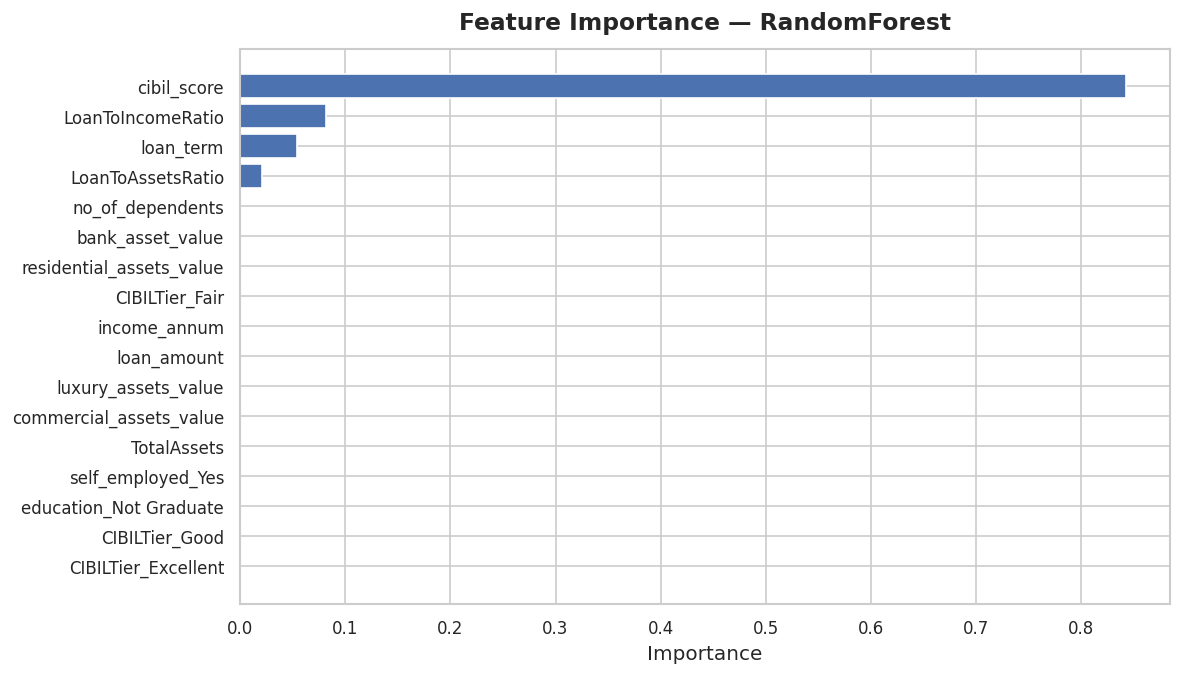

In [35]:
if hasattr(best_model, 'feature_importances_'):
    importances  = best_model.feature_importances_
    feature_names = (
        X_train_resampled.columns
        if hasattr(X_train_resampled, 'columns')
        else [f'Feature_{i}' for i in range(len(importances))]
    )

    idx = np.argsort(importances)
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(feature_names)[idx], importances[idx])
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.show()

else:
    print(f'{best_model_name} does NOT support feature_importances_')

In [36]:
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       323
           1       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

[[323   0]
 [  0 531]]


## Save Best Model
> We save the best model, Scaler, and selected Threshold so they can be reused in Production or for new inference without retraining.

In [37]:
joblib.dump(best_model, 'best_loan_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(best_t,     'best_threshold.pkl')
print('Model saved successfully')

Model saved successfully


---

##  Conclusion & Business Summary

---

###  Project Summary

| Stage | What Was Done |
|---|---|
| **Data Understanding** | Explored dataset shape, column types, and target distribution |
| **Data Cleaning** | Checked for duplicates, missing values, and outliers |
| **EDA** | Analyzed feature distributions and their relationship with Loan Status |
| **Feature Engineering** | Added LoanToIncomeRatio, TotalAssets, LoanToAssetsRatio, CIBILTier |
| **Preprocessing** | Encoding + SMOTE + Scaling in correct order |
| **Model Training** | Trained 4 models with Hyperparameter Tuning |
| **Cross-Validation** | Verified model generalization across 5 folds |
| **Model Evaluation** | Threshold Tuning + full Leaderboard comparison |
| **Feature Importance** | Identified the most influential features in the model |
| **Model Saving** | Saved best model, scaler, and threshold for production use |

---

###  Key Business Insights

- **CIBIL Score** is the strongest single predictor — applicants with scores above 750 are approved at a significantly higher rate.
- **Loan-to-Income Ratio** is a key risk indicator — applicants requesting amounts far exceeding their income are more likely to be rejected.
- **Total Assets** positively correlate with approval — greater financial strength reduces perceived risk.
- **Loan Term** plays a secondary role — longer terms slightly increase rejection risk.
- **Education and Self-Employment** have limited standalone impact but contribute when combined with financial features.

---

###  Business Recommendations

1. **Automated Pre-Screening:** Apply the model as the first filter on all incoming applications to rank them by approval probability.
2. **CIBIL Fast-Track:** Applicants with CIBIL > 750 and healthy income ratios can be fast-tracked with minimal manual review.
3. **Risk Tiering:** Use predicted probability to segment applicants into Low / Medium / High risk tiers and adjust interest rates accordingly.
4. **Asset Verification Priority:** Since total assets are highly predictive, invest in robust asset verification for borderline cases.
5. **Quarterly Model Refresh:** Retrain on fresh application data every quarter to adapt to shifts in borrower behavior and economic conditions.

---

###  Final Results

> The final model is capable of **accurately predicting loan approval decisions** with high F1 Score,
> enabling the Credit Risk team to **reduce defaults** while maintaining a healthy approval pipeline for qualified applicants.

---

*Built with: Python · Scikit-learn · Pandas · Seaborn · Imbalanced-learn*